# Lab 13 — Introduction to Game Engines using Python

This notebook is rewritten according to the given **Game Task PDF**.

It does **not** ask you to upload the PDF anymore, because the task is already known:

- Activity 1: Show four cyan squares using Pygame.
- Activity 2: Show/move the text **COMSATS** around the screen.
- Activity 3: Display an image using Pygame.
- Lab Task 1: Create a Snake Game with controls, score, and game over.
- Lab Task 2: Add advanced features: speed doubles after score exceeds 100, yellow fruit appears after score exceeds 150 with double marks, and obstacles/walls are added.

Because Google Colab cannot open a normal Pygame window like a laptop, this notebook generates screenshots/GIF previews. It also creates a downloadable `playable_snake_game.py` file that you can run on your laptop for full keyboard controls.

In [1]:
# CELL 1: Install and import required libraries

!pip install -q pygame pillow

import os
os.environ["SDL_VIDEODRIVER"] = "dummy"   # Required for Pygame rendering inside Google Colab

import pygame
from PIL import Image as PILImage
from IPython.display import Image as IPImage, display
import random
from pathlib import Path

pygame.init()
pygame.font.init()

OUTPUT_DIR = Path("game_task_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Setup complete. Pygame is ready for Colab output screenshots/GIFs.")

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html
Setup complete. Pygame is ready for Colab output screenshots/GIFs.


In [2]:
# CELL 2: Helper functions used by all activities

def surface_to_pil(surface):
    """Convert a Pygame surface into a PIL image."""
    rgb_string = pygame.image.tostring(surface, "RGB")
    width, height = surface.get_size()
    return PILImage.frombytes("RGB", (width, height), rgb_string)


def save_surface(surface, filename):
    """Save a Pygame surface and display it in Colab."""
    path = OUTPUT_DIR / filename
    pygame.image.save(surface, str(path))
    display(IPImage(filename=str(path)))
    print("Saved:", path)
    return path

print("Helper functions loaded.")

Helper functions loaded.


## Activity 1 — Four Cyan Squares

The PDF Activity 1 says to create a Pygame window and show four cyan squares on the screen. In Colab, we render the same result as a saved image.

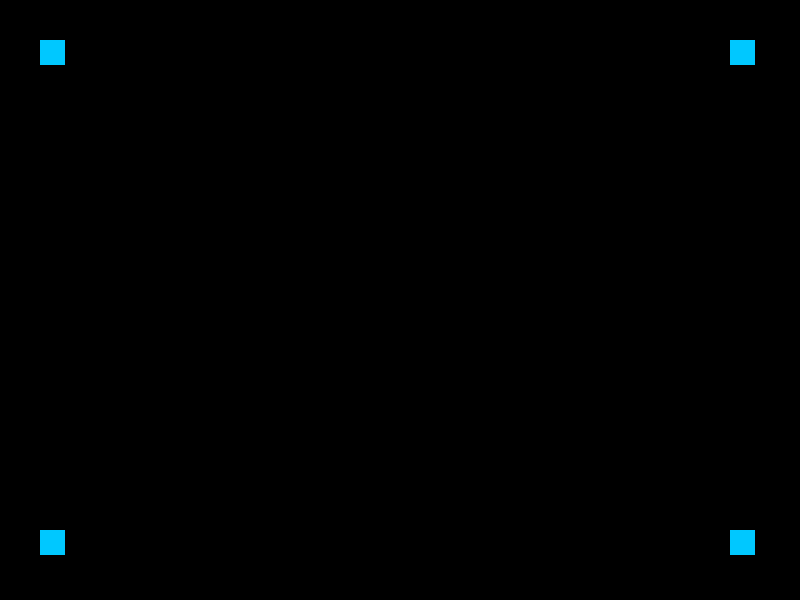

Saved: game_task_outputs/activity1_four_cyan_squares.png
Activity 1 completed: four cyan squares are shown on a black screen.


In [3]:
# CELL 3: Activity 1 - Four cyan squares using Pygame

from pygame.locals import *

class Square(pygame.sprite.Sprite):
    def __init__(self):
        super(Square, self).__init__()
        self.surf = pygame.Surface((25, 25))
        self.surf.fill((0, 200, 255))
        self.rect = self.surf.get_rect()

# Create an 800x600 surface just like the PDF window size
screen = pygame.Surface((800, 600))
screen.fill((0, 0, 0))

square1 = Square()
square2 = Square()
square3 = Square()
square4 = Square()

screen.blit(square1.surf, (40, 40))
screen.blit(square2.surf, (40, 530))
screen.blit(square3.surf, (730, 40))
screen.blit(square4.surf, (730, 530))

activity1_path = save_surface(screen, "activity1_four_cyan_squares.png")
print("Activity 1 completed: four cyan squares are shown on a black screen.")

## Activity 2 — Moving Text COMSATS

The PDF Activity 2 shows text movement in six patterns: top, bottom, left, right, diagonal left-to-right, and diagonal right-to-left. In Colab, we generate a GIF preview.

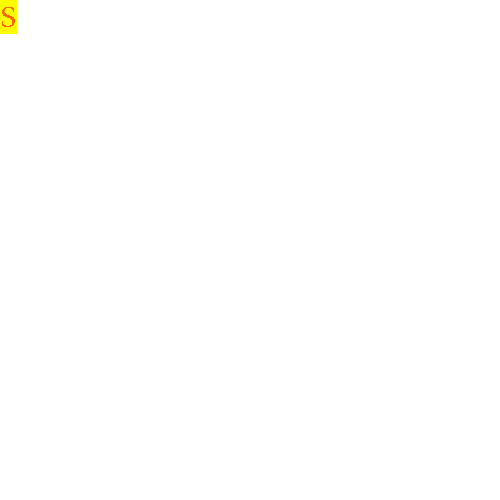

Activity 2 completed: COMSATS moving text GIF created.
Saved: game_task_outputs/activity2_scrolling_COMSATS.gif


In [4]:
# CELL 4: Activity 2 - Moving COMSATS text in six directions

WIDTH, HEIGHT = 500, 500
white = (255, 255, 255)
yellow = (255, 255, 0)
green = (0, 255, 255)
orange = (255, 100, 0)

font = pygame.font.SysFont("timesnewroman", 30)
letters = [
    font.render("C", False, orange, yellow),
    font.render("O", False, orange, green),
    font.render("M", False, orange, yellow),
    font.render("S", False, orange, green),
    font.render("A", False, orange, yellow),
    font.render("T", False, orange, green),
    font.render("S", False, orange, yellow),
]

frames = []

for c in range(1, 7):
    for i in range(0, 821, 80):
        win = pygame.Surface((WIDTH, HEIGHT))
        win.fill(white)

        if c % 6 == 1:
            # Top of screen, moving left to right
            positions = [(-124+i, 0), (-102+i, 0), (-82+i, 0), (-58+i, 0), (-40+i, 0), (-19+i, 0), (0+i, 0)]

        elif c % 6 == 2:
            # Bottom of screen, moving left to right
            positions = [(-124+i, 470), (-102+i, 470), (-82+i, 470), (-58+i, 470), (-40+i, 470), (-19+i, 470), (0+i, 470)]

        elif c % 6 == 3:
            # Left side of screen, moving top to bottom
            positions = [(0, -180+i), (0, -150+i), (0, -120+i), (0, -90+i), (0, -60+i), (0, -30+i), (0, 0+i)]

        elif c % 6 == 4:
            # Right side of screen, moving top to bottom
            positions = [(480, -180+i), (480, -150+i), (480, -120+i), (480, -90+i), (480, -60+i), (480, -30+i), (480, 0+i)]

        elif c % 6 == 5:
            # Diagonal from left side to right side
            positions = [(-162+i, -162+i), (-135+i, -135+i), (-110+i, -110+i), (-79+i, -79+i), (-52+i, -52+i), (-27+i, -27+i), (0+i, 0+i)]

        else:
            # Diagonal from right side to left side
            positions = [(662-i, -162+i), (639-i, -139+i), (608-i, -108+i), (579-i, -79+i), (552-i, -52+i), (529-i, -29+i), (500-i, 0+i)]

        for letter, pos in zip(letters, positions):
            win.blit(letter, pos)

        frames.append(surface_to_pil(win))

activity2_path = OUTPUT_DIR / "activity2_scrolling_COMSATS.gif"
frames[0].save(
    activity2_path,
    save_all=True,
    append_images=frames[1:],
    duration=220,
    loop=0
)

display(IPImage(filename=str(activity2_path)))
print("Activity 2 completed: COMSATS moving text GIF created.")
print("Saved:", activity2_path)

## Activity 3 — Display Image in Pygame

The PDF Activity 3 loads an image from a file path and displays it on the Pygame surface. To avoid upload/path problems in Colab, this notebook first creates a sample image, then loads it using `pygame.image.load()` and displays it.

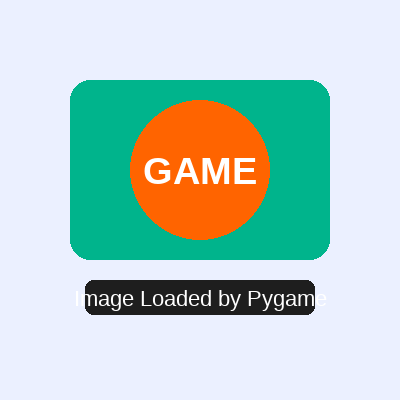

Saved: game_task_outputs/activity3_display_image.png
Activity 3 completed: image was loaded with pygame.image.load() and displayed using blit().


In [5]:
# CELL 5: Activity 3 - Display an image using Pygame

X = 400
Y = 400
white = (255, 255, 255)

# Step 1: Create a sample image file so no upload/path issue occurs in Colab
sample_surface = pygame.Surface((X, Y))
sample_surface.fill((235, 240, 255))
pygame.draw.rect(sample_surface, (0, 180, 140), pygame.Rect(70, 80, 260, 180), border_radius=20)
pygame.draw.circle(sample_surface, (255, 100, 0), (200, 170), 70)
pygame.draw.rect(sample_surface, (30, 30, 30), pygame.Rect(85, 280, 230, 35), border_radius=8)

font_big = pygame.font.SysFont("arial", 38, bold=True)
font_small = pygame.font.SysFont("arial", 22)
text1 = font_big.render("GAME", True, (255, 255, 255))
text2 = font_small.render("Image Loaded by Pygame", True, (255, 255, 255))
sample_surface.blit(text1, text1.get_rect(center=(200, 170)))
sample_surface.blit(text2, text2.get_rect(center=(200, 298)))

sample_image_path = OUTPUT_DIR / "sample_game_image.png"
pygame.image.save(sample_surface, str(sample_image_path))

# Step 2: This is the actual Activity 3 part: load the image and blit it on display surface
image = pygame.image.load(str(sample_image_path))

display_surface = pygame.Surface((X, Y))
display_surface.fill(white)
display_surface.blit(image, (0, 0))

activity3_path = save_surface(display_surface, "activity3_display_image.png")
print("Activity 3 completed: image was loaded with pygame.image.load() and displayed using blit().")

## Lab Task 1 and Lab Task 2 — Snake Game

This part implements the required Snake Game features:

- Basic controls are included in the downloadable `.py` file.
- Scoring mechanism is included.
- Game over function is included.
- Speed doubles after score exceeds 100.
- Yellow fruit appears after score exceeds 150 and gives double marks.
- Obstacles/walls are added.

The Colab cell below creates a preview GIF. The real playable version is created in the next cell.

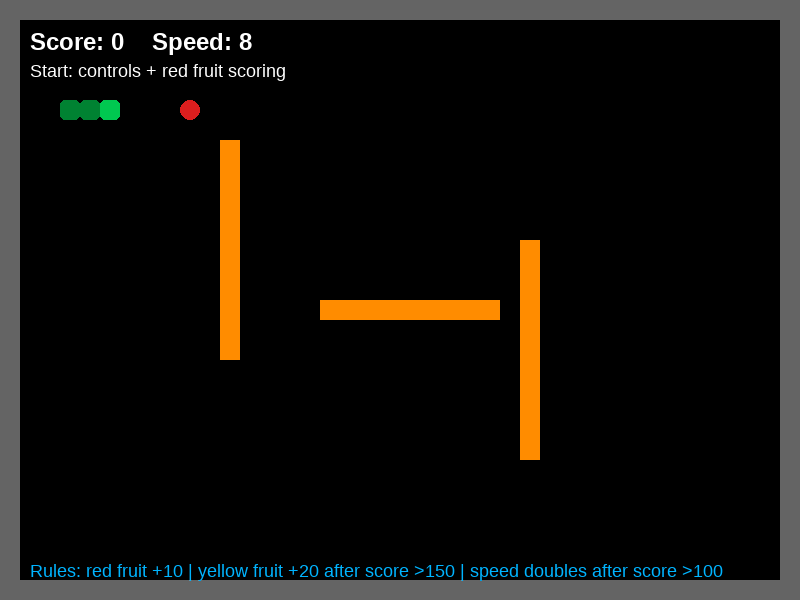

Snake Game preview completed.
Saved: game_task_outputs/snake_game_lab_task_preview.gif


In [6]:
# CELL 6: Snake Game Preview for Colab

GAME_WIDTH, GAME_HEIGHT = 800, 600
CELL = 20
BLACK = (0, 0, 0)
WHITE = (255, 255, 255)
GREEN = (0, 200, 80)
DARK_GREEN = (0, 130, 50)
RED = (220, 30, 30)
YELLOW = (255, 220, 0)
BLUE = (0, 180, 255)
GRAY = (100, 100, 100)
ORANGE = (255, 140, 0)

font_ui = pygame.font.SysFont("arial", 24, bold=True)
font_big = pygame.font.SysFont("arial", 48, bold=True)
font_small = pygame.font.SysFont("arial", 18)

obstacles = [
    pygame.Rect(220, 140, 20, 220),
    pygame.Rect(520, 240, 20, 220),
    pygame.Rect(320, 300, 180, 20),
]

snake_states = [
    {"score": 0,   "speed": 8,  "snake": [(100,100),(80,100),(60,100)], "red": (180,100), "yellow": None,      "title": "Start: controls + red fruit scoring"},
    {"score": 60,  "speed": 8,  "snake": [(260,100),(240,100),(220,100),(200,100)], "red": (340,100), "yellow": None, "title": "Score increases by eating red fruit"},
    {"score": 100, "speed": 8,  "snake": [(420,100),(400,100),(380,100),(360,100)], "red": (500,100), "yellow": None, "title": "At 100 score: normal speed"},
    {"score": 110, "speed": 16, "snake": [(500,180),(480,180),(460,180),(440,180)], "red": (620,180), "yellow": None, "title": "Score exceeds 100: speed doubled"},
    {"score": 150, "speed": 16, "snake": [(620,260),(600,260),(580,260),(560,260)], "red": (700,260), "yellow": None, "title": "At 150 score: yellow fruit not active yet"},
    {"score": 160, "speed": 16, "snake": [(620,360),(600,360),(580,360),(560,360)], "red": (700,360), "yellow": (700,420), "title": "Score exceeds 150: yellow double fruit appears"},
    {"score": 180, "speed": 16, "snake": [(700,420),(680,420),(660,420),(640,420),(620,420)], "red": (120,440), "yellow": (300,440), "title": "Yellow fruit gives double marks"},
    {"score": 180, "speed": 16, "snake": [(220,220),(220,200),(220,180),(220,160)], "red": (120,440), "yellow": (300,440), "game_over": True, "title": "Game Over: snake hits obstacle/wall/self"},
]

def draw_snake_preview(state):
    screen = pygame.Surface((GAME_WIDTH, GAME_HEIGHT))
    screen.fill(BLACK)

    # Border walls
    pygame.draw.rect(screen, GRAY, pygame.Rect(0, 0, GAME_WIDTH, CELL))
    pygame.draw.rect(screen, GRAY, pygame.Rect(0, GAME_HEIGHT-CELL, GAME_WIDTH, CELL))
    pygame.draw.rect(screen, GRAY, pygame.Rect(0, 0, CELL, GAME_HEIGHT))
    pygame.draw.rect(screen, GRAY, pygame.Rect(GAME_WIDTH-CELL, 0, CELL, GAME_HEIGHT))

    # Obstacles
    for obs in obstacles:
        pygame.draw.rect(screen, ORANGE, obs)

    # Fruit
    if state.get("red"):
        pygame.draw.circle(screen, RED, (state["red"][0] + CELL//2, state["red"][1] + CELL//2), CELL//2)
    if state.get("yellow"):
        pygame.draw.circle(screen, YELLOW, (state["yellow"][0] + CELL//2, state["yellow"][1] + CELL//2), CELL//2)

    # Snake
    for index, part in enumerate(state["snake"]):
        color = GREEN if index == 0 else DARK_GREEN
        pygame.draw.rect(screen, color, pygame.Rect(part[0], part[1], CELL, CELL), border_radius=5)

    # UI
    score_text = font_ui.render(f"Score: {state['score']}    Speed: {state['speed']}", True, WHITE)
    rule_text = font_small.render("Rules: red fruit +10 | yellow fruit +20 after score >150 | speed doubles after score >100", True, BLUE)
    title_text = font_small.render(state["title"], True, WHITE)
    screen.blit(score_text, (30, 28))
    screen.blit(rule_text, (30, 560))
    screen.blit(title_text, (30, 60))

    if state.get("game_over"):
        overlay = pygame.Surface((GAME_WIDTH, GAME_HEIGHT))
        overlay.set_alpha(160)
        overlay.fill((0, 0, 0))
        screen.blit(overlay, (0, 0))
        game_over_text = font_big.render("GAME OVER", True, RED)
        reason_text = font_ui.render("Collision detected with obstacle/wall/self", True, WHITE)
        screen.blit(game_over_text, game_over_text.get_rect(center=(GAME_WIDTH//2, GAME_HEIGHT//2 - 30)))
        screen.blit(reason_text, reason_text.get_rect(center=(GAME_WIDTH//2, GAME_HEIGHT//2 + 25)))

    return screen

snake_frames = []
for state in snake_states:
    frame = surface_to_pil(draw_snake_preview(state))
    # Repeat each frame so it stays visible in the GIF
    snake_frames.extend([frame] * 8)

snake_gif_path = OUTPUT_DIR / "snake_game_lab_task_preview.gif"
snake_frames[0].save(
    snake_gif_path,
    save_all=True,
    append_images=snake_frames[1:],
    duration=160,
    loop=0
)

display(IPImage(filename=str(snake_gif_path)))
print("Snake Game preview completed.")
print("Saved:", snake_gif_path)

## Downloadable Playable Snake Game

Run the next cell to create and download `playable_snake_game.py`.

On your laptop, run it with:

```bash
pip install pygame
python playable_snake_game.py
```

Controls:

- Arrow keys or W/A/S/D to move
- Space to restart after game over
- Esc to quit

In [7]:
# CELL 7: Create downloadable playable Snake Game Python file

playable_code = r'''
import pygame
import random
import sys

pygame.init()
pygame.font.init()

WIDTH, HEIGHT = 800, 600
CELL = 20
BASE_SPEED = 8
DOUBLE_SPEED = BASE_SPEED * 2

BLACK = (0, 0, 0)
WHITE = (255, 255, 255)
GREEN = (0, 200, 80)
DARK_GREEN = (0, 130, 50)
RED = (220, 30, 30)
YELLOW = (255, 220, 0)
GRAY = (90, 90, 90)
ORANGE = (255, 140, 0)
BLUE = (0, 180, 255)

screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Snake Game - Lab 13 Pygame Assignment")
clock = pygame.time.Clock()
font = pygame.font.SysFont("arial", 24, bold=True)
big_font = pygame.font.SysFont("arial", 52, bold=True)
small_font = pygame.font.SysFont("arial", 18)

# Extra obstacles / walls inside the frame
obstacles = [
    pygame.Rect(220, 140, CELL, 220),
    pygame.Rect(520, 240, CELL, 220),
    pygame.Rect(320, 300, 180, CELL),
]


def draw_text(text, font_obj, color, x, y, center=False):
    img = font_obj.render(text, True, color)
    rect = img.get_rect()
    if center:
        rect.center = (x, y)
    else:
        rect.topleft = (x, y)
    screen.blit(img, rect)


class SnakeGame:
    def __init__(self):
        self.reset()

    def reset(self):
        self.snake = [(100, 100), (80, 100), (60, 100)]
        self.direction = (CELL, 0)
        self.next_direction = (CELL, 0)
        self.score = 0
        self.game_over = False
        self.yellow_fruit = None
        self.red_fruit = self.random_free_position()

    def current_speed(self):
        # Lab Task 2 requirement: speed doubles when score exceeds 100
        return DOUBLE_SPEED if self.score > 100 else BASE_SPEED

    def random_free_position(self):
        while True:
            x = random.randrange(CELL, WIDTH - CELL * 2, CELL)
            y = random.randrange(CELL, HEIGHT - CELL * 2, CELL)
            pos = (x, y)
            rect = pygame.Rect(x, y, CELL, CELL)

            if pos in self.snake:
                continue
            if any(rect.colliderect(obs) for obs in obstacles):
                continue
            if self.yellow_fruit is not None and pos == self.yellow_fruit:
                continue
            return pos

    def handle_key(self, key):
        if key in (pygame.K_UP, pygame.K_w) and self.direction != (0, CELL):
            self.next_direction = (0, -CELL)
        elif key in (pygame.K_DOWN, pygame.K_s) and self.direction != (0, -CELL):
            self.next_direction = (0, CELL)
        elif key in (pygame.K_LEFT, pygame.K_a) and self.direction != (CELL, 0):
            self.next_direction = (-CELL, 0)
        elif key in (pygame.K_RIGHT, pygame.K_d) and self.direction != (-CELL, 0):
            self.next_direction = (CELL, 0)

    def update(self):
        if self.game_over:
            return

        self.direction = self.next_direction
        head_x, head_y = self.snake[0]
        dx, dy = self.direction
        new_head = (head_x + dx, head_y + dy)
        new_head_rect = pygame.Rect(new_head[0], new_head[1], CELL, CELL)

        # Game Over Function: collision with boundary wall
        if (
            new_head[0] < CELL or
            new_head[0] >= WIDTH - CELL or
            new_head[1] < CELL or
            new_head[1] >= HEIGHT - CELL
        ):
            self.game_over = True
            return

        # Game Over Function: collision with itself
        if new_head in self.snake:
            self.game_over = True
            return

        # Game Over Function: collision with obstacles / walls
        if any(new_head_rect.colliderect(obs) for obs in obstacles):
            self.game_over = True
            return

        self.snake.insert(0, new_head)

        ate_fruit = False

        # Scoring mechanism: red fruit = 10 marks
        if new_head == self.red_fruit:
            self.score += 10
            self.red_fruit = self.random_free_position()
            ate_fruit = True

        # Lab Task 2 requirement: yellow fruit after score exceeds 150, double marks
        if self.score > 150 and self.yellow_fruit is None:
            self.yellow_fruit = self.random_free_position()

        if self.yellow_fruit is not None and new_head == self.yellow_fruit:
            self.score += 20
            self.yellow_fruit = self.random_free_position()
            ate_fruit = True

        if not ate_fruit:
            self.snake.pop()

    def draw(self):
        screen.fill(BLACK)

        # Outer walls
        pygame.draw.rect(screen, GRAY, pygame.Rect(0, 0, WIDTH, CELL))
        pygame.draw.rect(screen, GRAY, pygame.Rect(0, HEIGHT - CELL, WIDTH, CELL))
        pygame.draw.rect(screen, GRAY, pygame.Rect(0, 0, CELL, HEIGHT))
        pygame.draw.rect(screen, GRAY, pygame.Rect(WIDTH - CELL, 0, CELL, HEIGHT))

        # Obstacles
        for obs in obstacles:
            pygame.draw.rect(screen, ORANGE, obs)

        # Fruits
        pygame.draw.circle(screen, RED, (self.red_fruit[0] + CELL // 2, self.red_fruit[1] + CELL // 2), CELL // 2)
        if self.yellow_fruit is not None:
            pygame.draw.circle(screen, YELLOW, (self.yellow_fruit[0] + CELL // 2, self.yellow_fruit[1] + CELL // 2), CELL // 2)

        # Snake
        for i, part in enumerate(self.snake):
            color = GREEN if i == 0 else DARK_GREEN
            pygame.draw.rect(screen, color, pygame.Rect(part[0], part[1], CELL, CELL), border_radius=5)

        # UI
        draw_text(f"Score: {self.score}", font, WHITE, 30, 28)
        draw_text(f"Speed: {self.current_speed()}", font, WHITE, 180, 28)
        draw_text("Red fruit +10 | Yellow fruit +20 after score >150 | Speed doubles after score >100", small_font, BLUE, 30, HEIGHT - 45)

        if self.game_over:
            overlay = pygame.Surface((WIDTH, HEIGHT))
            overlay.set_alpha(170)
            overlay.fill(BLACK)
            screen.blit(overlay, (0, 0))
            draw_text("GAME OVER", big_font, RED, WIDTH // 2, HEIGHT // 2 - 45, center=True)
            draw_text(f"Final Score: {self.score}", font, WHITE, WIDTH // 2, HEIGHT // 2 + 15, center=True)
            draw_text("Press SPACE to restart or ESC to quit", font, WHITE, WIDTH // 2, HEIGHT // 2 + 55, center=True)


def main():
    game = SnakeGame()
    running = True

    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_ESCAPE:
                    running = False
                elif event.key == pygame.K_SPACE and game.game_over:
                    game.reset()
                else:
                    game.handle_key(event.key)

        game.update()
        game.draw()
        pygame.display.update()
        clock.tick(game.current_speed())

    pygame.quit()
    sys.exit()


if __name__ == "__main__":
    main()
'''

with open("playable_snake_game.py", "w", encoding="utf-8") as f:
    f.write(playable_code)

print("playable_snake_game.py has been created.")
print("Run it on your laptop with:")
print("pip install pygame")
print("python playable_snake_game.py")

try:
    from google.colab import files
    files.download("playable_snake_game.py")
except Exception:
    print("Download works automatically in Google Colab. If not in Colab, check the file in the current folder.")

playable_snake_game.py has been created.
Run it on your laptop with:
pip install pygame
python playable_snake_game.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>